# 01 — How the 72 windows per pair were chosen

"We picked 72 windows" is the step in the design a reader is most entitled to
distrust, so this notebook shows the rule rather than asserting it: every day of
2024, the tercile cuts computed from those days, and which days the rule took.

The rule is fixed in `experiments/windows.py` and was written before any result
existed: split the year's daily realised volatility into terciles, take the same
number of days from each -- 24 per tercile since the power extension, so 72
per pair. No day is chosen by hand.

**Needs:** the Binance kline cache in `data/`. The first run fetches a year and
takes about fifteen minutes; afterwards it is offline. If a window re-fetches,
the cache key is wrong — that breaks reproducibility, so investigate rather than
wait it out.


In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))

from experiments.figures import volatility_stratification
from experiments.matrix import load_segments

FIGURES = ROOT / "paper" / "Image"
FIGURES.mkdir(parents=True, exist_ok=True)
ROOT

PosixPath('/Users/antonled/science/uniswapv4-hooks/swap-hooks')

In [2]:
# all_days: every day of 2024 per pair. selected: the 72 the rule took.
all_days, selected = load_segments()

pd.DataFrame(
    [
        {
            "pair": pair,
            "days_in_year": len(days),
            "selected": len(selected[pair]),
            "per_regime": selected[pair]["regime"].value_counts().to_dict(),
        }
        for pair, days in all_days.items()
    ]
)

,pair,days_in_year,selected,per_regime
0,ETH/SHIB,366,72,"{'low': 24, 'mid': 24, 'high': 24}"
1,ETH/USDC,366,72,"{'low': 24, 'mid': 24, 'high': 24}"
2,USDC/USDT,366,72,"{'low': 24, 'mid': 24, 'high': 24}"


## The tercile cuts, and where they carry no information

The ratio between the two cuts says whether the regime axis means anything for a
given pair. A cut ratio near 1 means the "low" and "high" windows are the same
windows under another name.


In [3]:
cuts = []
for pair, days in all_days.items():
    lo, hi = days["volatility"].quantile([1 / 3, 2 / 3])
    cuts.append(
        {
            "pair": pair,
            "min": days["volatility"].min(),
            "cut_low_mid": lo,
            "cut_mid_high": hi,
            "max": days["volatility"].max(),
            "cut_ratio": hi / lo,
        }
    )
pd.DataFrame(cuts).set_index("pair").round(5)

,min,cut_low_mid,cut_mid_high,max,cut_ratio
pair,,,,,
ETH/SHIB,0.01748,0.03240,0.04207,0.30036,1.29847
ETH/USDC,0.01037,0.02521,0.03279,0.17378,1.30098
USDC/USDT,0.00093,0.00256,0.00266,0.00378,1.03821


`USDC/USDT` is the case in point: its terciles differ by a few percent, against
roughly thirty for the volatile pairs. Its regime axis is not a weak signal, it
is no signal — the pair is structurally degenerate for this design, which is why
it also produces almost no trades. That is a finding about where dynamic fees
apply, not a fault in the run.


In [4]:
out = FIGURES / "volatility_stratification.pdf"
volatility_stratification(all_days, selected, out)
print(f"wrote {out} and {out.with_suffix('.csv')}")

wrote /Users/antonled/science/uniswapv4-hooks/swap-hooks/paper/Image/volatility_stratification.pdf and /Users/antonled/science/uniswapv4-hooks/swap-hooks/paper/Image/volatility_stratification.csv


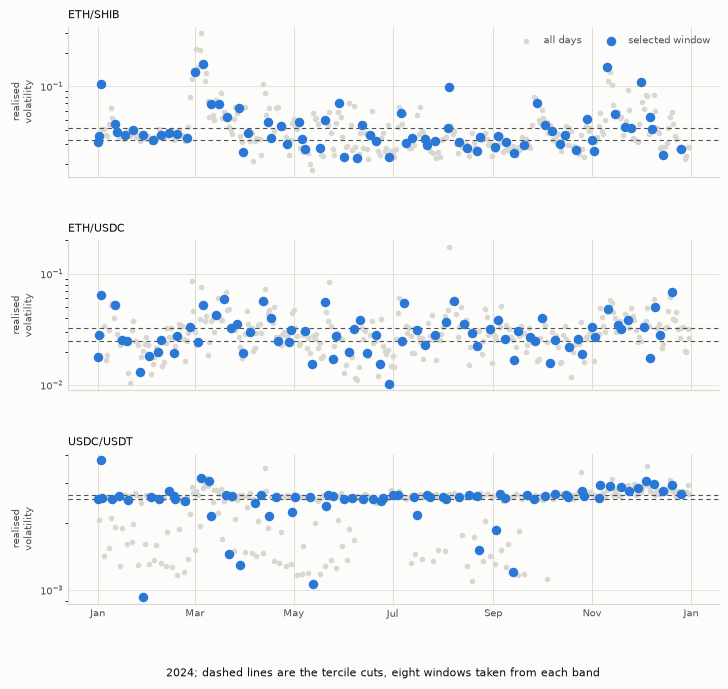

In [5]:
from IPython.display import Image, display

# Rendered as PNG for display only; the PDF beside it is what the paper uses.
preview = FIGURES / "volatility_stratification.png"
volatility_stratification(all_days, selected, preview)
display(Image(filename=str(preview)))

## The windows this pins

These start timestamps are field `W` of the reproducibility manifest
(Eq. 9). Two runs on the same nominal month and pair diverge without them.


In [6]:
chosen = pd.concat(
    [df.assign(pair=pair) for pair, df in selected.items()], ignore_index=True
)
chosen["day"] = pd.to_datetime(chosen["start_ms"], unit="ms").dt.date
chosen.pivot_table(
    index="day", columns="pair", values="regime", aggfunc="first"
).dropna(how="all").head(30)

pair,ETH/SHIB,ETH/USDC,USDC/USDT
day,,,
2024-01-01,low,low,low
2024-01-02,mid,mid,NaN
2024-01-03,high,high,high
2024-01-04,NaN,NaN,mid
2024-01-10,NaN,NaN,low
2024-01-12,high,high,NaN
2024-01-13,mid,NaN,NaN
2024-01-14,NaN,NaN,mid
2024-01-16,NaN,mid,NaN
